NLP Project: DIsaster Tweet Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [3]:
df = pd.read_csv('twitter_disaster.csv')

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


In [6]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# Class Distribution

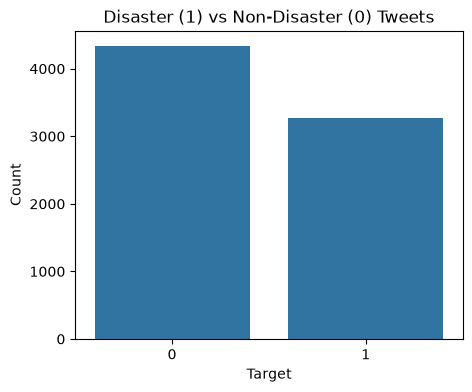

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Disaster (1) vs Non-Disaster (0) Tweets')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()
print(df['target'].value_counts(normalize=True))

Most frequent keywords in disaster vs non-disaster

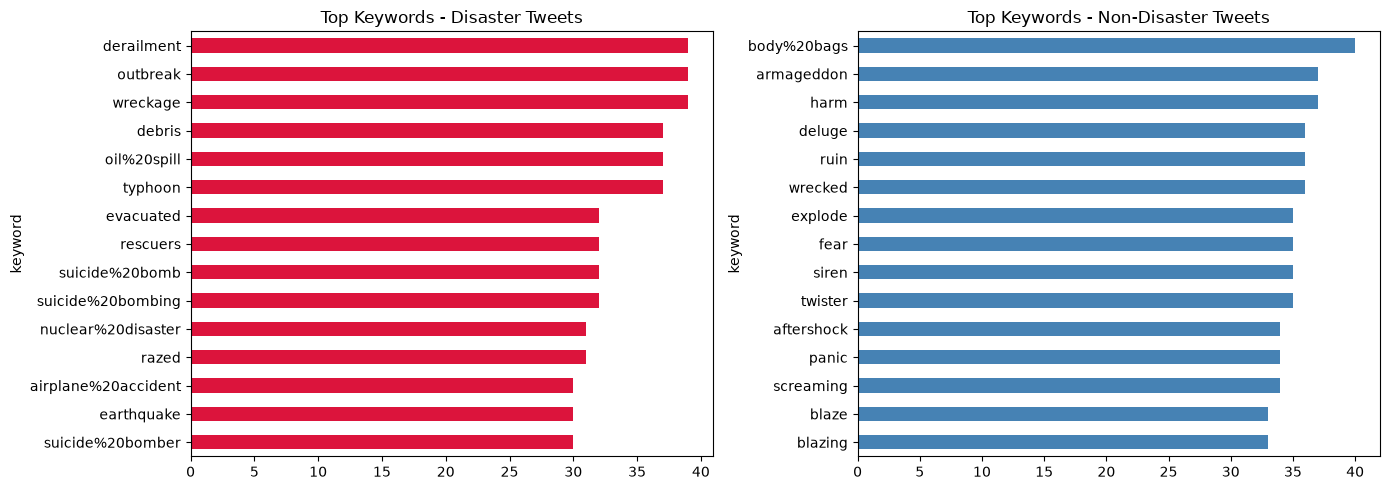

In [9]:
top_disaster_kw = df[df['target']==1]['keyword'].value_counts().head(15)
top_nondisaster_kw = df[df['target']==0]['keyword'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Disaster
top_disaster_kw.plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Top Keywords - Disaster Tweets')
axes[0].invert_yaxis()

# Non-disaster
top_nondisaster_kw.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top Keywords - Non-Disaster Tweets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [11]:
#Text Cleaning

In [12]:
# I have removing URLS, mentions, hastag word, drop symbol, punctuation, numbers, extra whitespace

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'https? : //\S+|www\.\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#', '', text)
  text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)


,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed in both...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,i m on top of the hill and i can see a fire in...
8,There's an emergency evacuation happening now ...,there s an emergency evacuation happening now ...
9,I'm afraid that the tornado is coming to our a...,i m afraid that the tornado is coming to our area


# Tokenization

In [13]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())
df['token_count'] = df['tokens'].apply(len)

df[['clean_text', 'tokens', 'token_count']].head()

,clean_text,tokens,token_count
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth...",13
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]",7
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place...",22
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order...",7
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala...",16


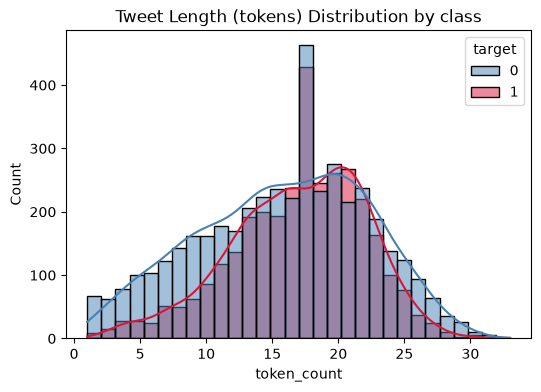

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='token_count', hue='target', bins=30, kde=True, palette=['steelblue', 'crimson'])
plt.title('Tweet Length (tokens) Distribution by class')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
X = df['clean_text']
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size", X_train.shape[0])
print("Train size", X_test.shape[0])

Train size 6090
Train size 1523


# Feature Engineering and Model Selection

TF-IDF Feature Extraction

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrict shape (train):", X_train_tfidf.shape)

TF-IDF matrict shape (train): (6090, 5000)


# Additional engineering feature (tweet length, hashtag count, mention count

In [17]:
def extra_features(raw_text_series):
  hashtag = raw_text_series.apply(lambda t: len(re.findall(r'#\w+', str(t))))
  mentions = raw_text_series.apply(lambda t: len(re.findall(r'@\w+', str(t))))
  length = raw_text_series.apply(lambda t: len(str(t)))
  return pd.DataFrame({'hashtag' : hashtag, 'mentions' : mentions, 'length': length})

train_extra = extra_features(df.loc[X_train.index, 'text'])
test_extra = extra_features(df.loc[X_test.index, 'text'])
train_extra.head()

,hashtag,mentions,length
6234,3,0,116
326,0,0,135
997,1,0,86
7269,0,1,41
2189,0,0,102


# Model candidates: Logistic Regression, Multinominal Naive Bayes, Random Forest

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinominal Naive Bayes' : MultinomialNB(),
    'Random Forest' : RandomForestClassifier(n_estimators=200, random_state=42)
}

cv_results = {}
for name, model in models.items():
  scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1')
  cv_results[name] = scores
  print(f"{name}: mean F1 = {scores.mean(): .4f} (+/- {scores.std(): .4f})")

Logistic Regression: mean F1 =  0.7332 (+/-  0.0158)
Multinominal Naive Bayes: mean F1 =  0.7277 (+/-  0.0101)
Random Forest: mean F1 =  0.7146 (+/-  0.0125)


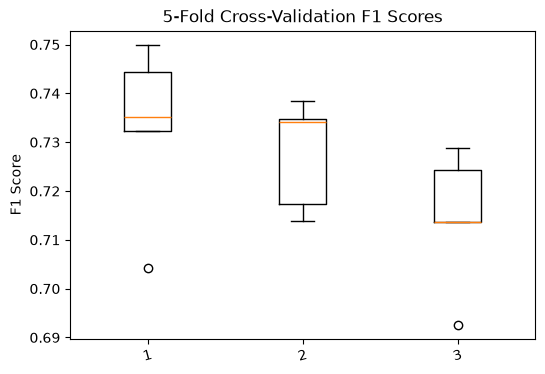

In [20]:
plt.figure(figsize=(6,4))
plt.boxplot(cv_results.values(), label=cv_results.keys())
plt.title('5-Fold Cross-Validation F1 Scores')
plt.ylabel('F1 Score')
plt.xticks(rotation=15)
plt.show()

# Hypreparameter tuning (Logistic Regression via Gridsearch CV

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.01, 0.1, 1, 10],
    'penalty' : ['l2'],
    'solver' : ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.7325703631664451


d:\NextHikes\NextHikes Python Project 8\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


# Model Evaluation and validation

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve )
y_pred = best_model.predict(X_test_tfidf)
y_proba = best_model.predict_proba(X_test_tfidf)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Not Disaster', 'Disaster']))


Accuracy: 0.8161523309258043
Precision: 0.8375451263537906
Recall: 0.709480122324159
F1-score: 0.7682119205298014

              precision    recall  f1-score   support

Not Disaster       0.80      0.90      0.85       869
    Disaster       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523



#Confusion Metrix

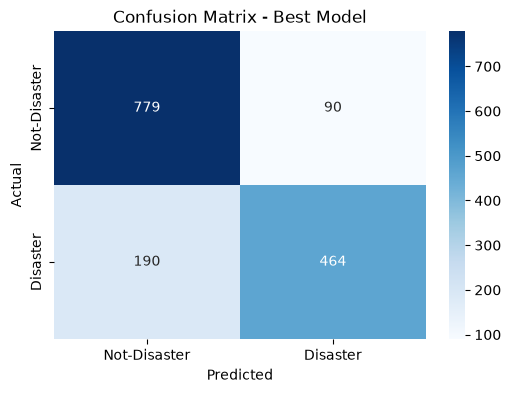

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not-Disaster', 'Disaster'], yticklabels=['Not-Disaster', 'Disaster'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()

# ROC Curve

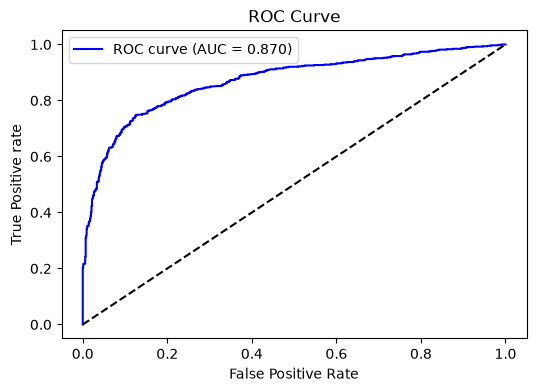

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='Blue')
plt.plot([0,1], [0,1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Precision - Recall Curve

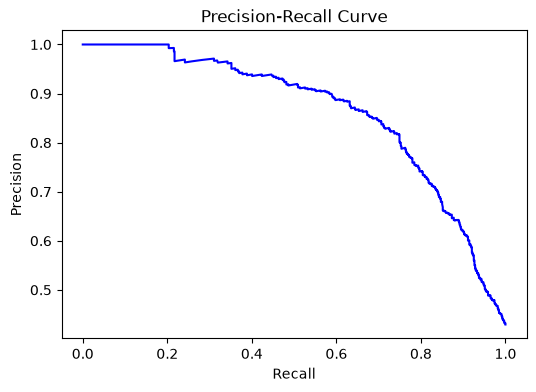

In [25]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(rec, prec, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Overfitting / Underfitting Check

#Compare training vs Test performance to make sure te model generalizes well.

In [26]:
train_pred = best_model.predict(X_train_tfidf)
print("Train F1:", f1_score(y_train, train_pred))
print("Train F1:", f1_score(y_test, y_pred))
print("\nA small gap between train and test F1 indicates the model is generalizing well,")
print("rather than overfitting to the training data.")

Train F1: 0.8280922431865828
Train F1: 0.7682119205298014

A small gap between train and test F1 indicates the model is generalizing well,
rather than overfitting to the training data.


# Model Conparison Summary

In [27]:
summary = pd.DataFrame({
    'Model' : list(cv_results.keys()),
    'Mean CV F1' : [scores.mean() for scores in cv_results.values()]
}).sort_values('Mean CV F1', ascending=False)
summary

,Model,Mean CV F1
0,Logistic Regression,0.733193
1,Multinominal Naive Bayes,0.727727
2,Random Forest,0.714642


## Part 4: Deployment with Web Interface

### Serialize the trained model

In [28]:
import pickle

with open('disaster_tweet_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved.")

Model and vectorizer saved.
